## 1. Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from module_function import GaussianMixtureClustering,ClusteringVisualizer

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
df = pd.read_csv('dataset/EastWestAirlines_CLEANING.csv')
df.head(3)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0


## 2. Feature Scaling

In [3]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy="mean")),
    ('scaler',RobustScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas")
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Balance,num__Qual_miles,num__cc1_miles,num__cc2_miles,num__cc3_miles,num__Bonus_miles,num__Bonus_trans,num__Flight_miles_12mo,num__Flight_trans_12,num__Days_since_enroll,num__Award
0,-0.202990,0.0,0.0,0.0,0.0,-0.310672,-0.785714,0.000000,0.0,0.838994,0.0
1,-0.323457,0.0,0.0,0.0,0.0,-0.308855,-0.714286,0.000000,0.0,0.829744,0.0
2,-0.024150,0.0,0.0,0.0,0.0,-0.135634,-0.571429,0.000000,0.0,0.848822,0.0
3,-0.383941,0.0,0.0,0.0,0.0,-0.296222,-0.785714,0.000000,0.0,0.825119,0.0
4,0.739318,0.0,1.5,0.0,0.0,1.600878,1.000000,6.625199,4.0,0.820205,1.0


## 3. The Analysis K Selection in GMM

In [4]:
cluster_model = GaussianMixtureClustering(range_max=12, df_raw=df)
cluster_model.fit_model(X_cleaned)
cluster_model.compute_scores_dataframe()

[INFO] Model berhasil dilatih untuk semua rentang k.


,n_clusters(k),BIC Score,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Composite_Score
0,2,-47361.616627,0.851691,1792.631750,1.040602,0.784213
1,3,-61871.387156,0.035790,74.665650,2.180514,0.172016
2,4,-58132.647979,0.682125,444.612827,2.017146,0.484506
3,5,-58191.152227,0.688109,1205.096920,2.003430,0.540925
4,6,-58082.748004,0.681086,1735.105944,2.173391,0.550267
5,7,-56967.428553,0.717092,3622.046295,1.307943,0.816560
6,8,-103813.488670,0.052681,727.008622,3.396030,0.051535
7,9,-103525.308830,0.052202,723.940615,3.031734,0.102684
8,10,-129074.499745,0.368428,4946.424736,1.189707,0.781464
9,11,-132483.835082,0.340415,1671.580522,2.069966,0.421378


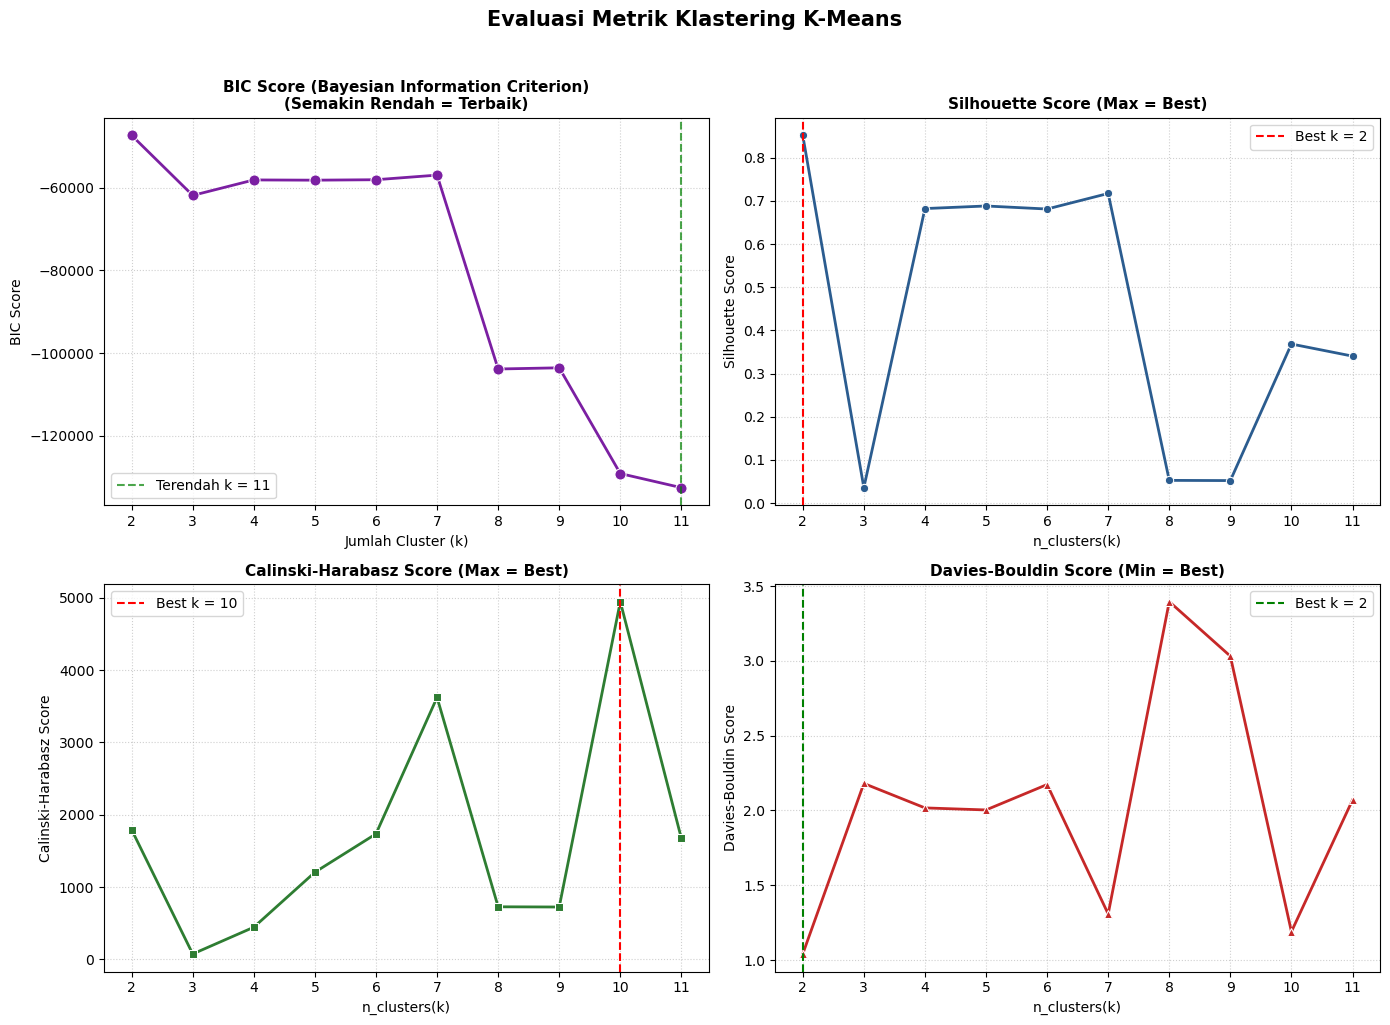

In [5]:
visualizer = ClusteringVisualizer(cluster_model)
visualizer.plot_evaluation_metrics()

[INFO] Model optimal dipilih dengan jumlah cluster (k) = 7


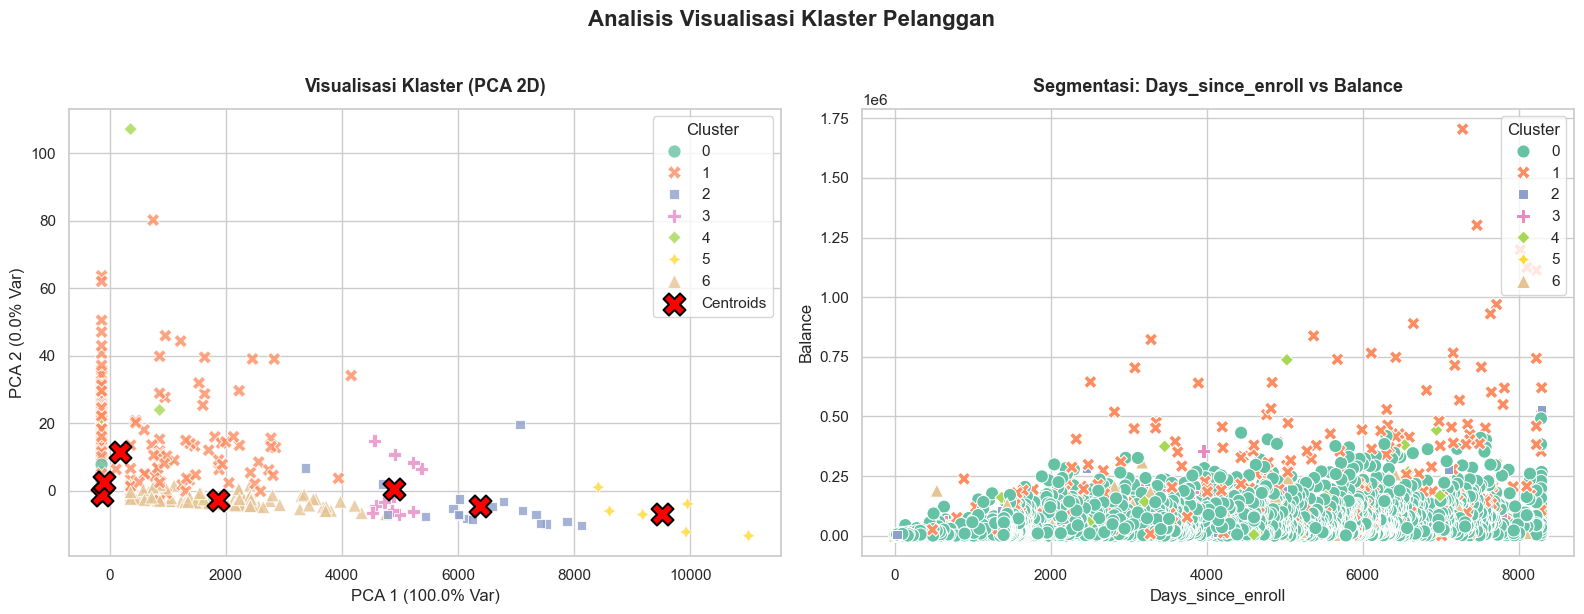

In [8]:
best_gmm, df_clustered = cluster_model.fit_best_model(X_cleaned)
visualizer.plot_cluster_results(
    X_cleaned=X_cleaned, 
    best_gmm=best_gmm, 
    feature_x='Days_since_enroll',   # Sesuaikan dengan nama kolom dataset Anda
    feature_y='Balance' # Sesuaikan dengan nama kolom dataset Anda
)

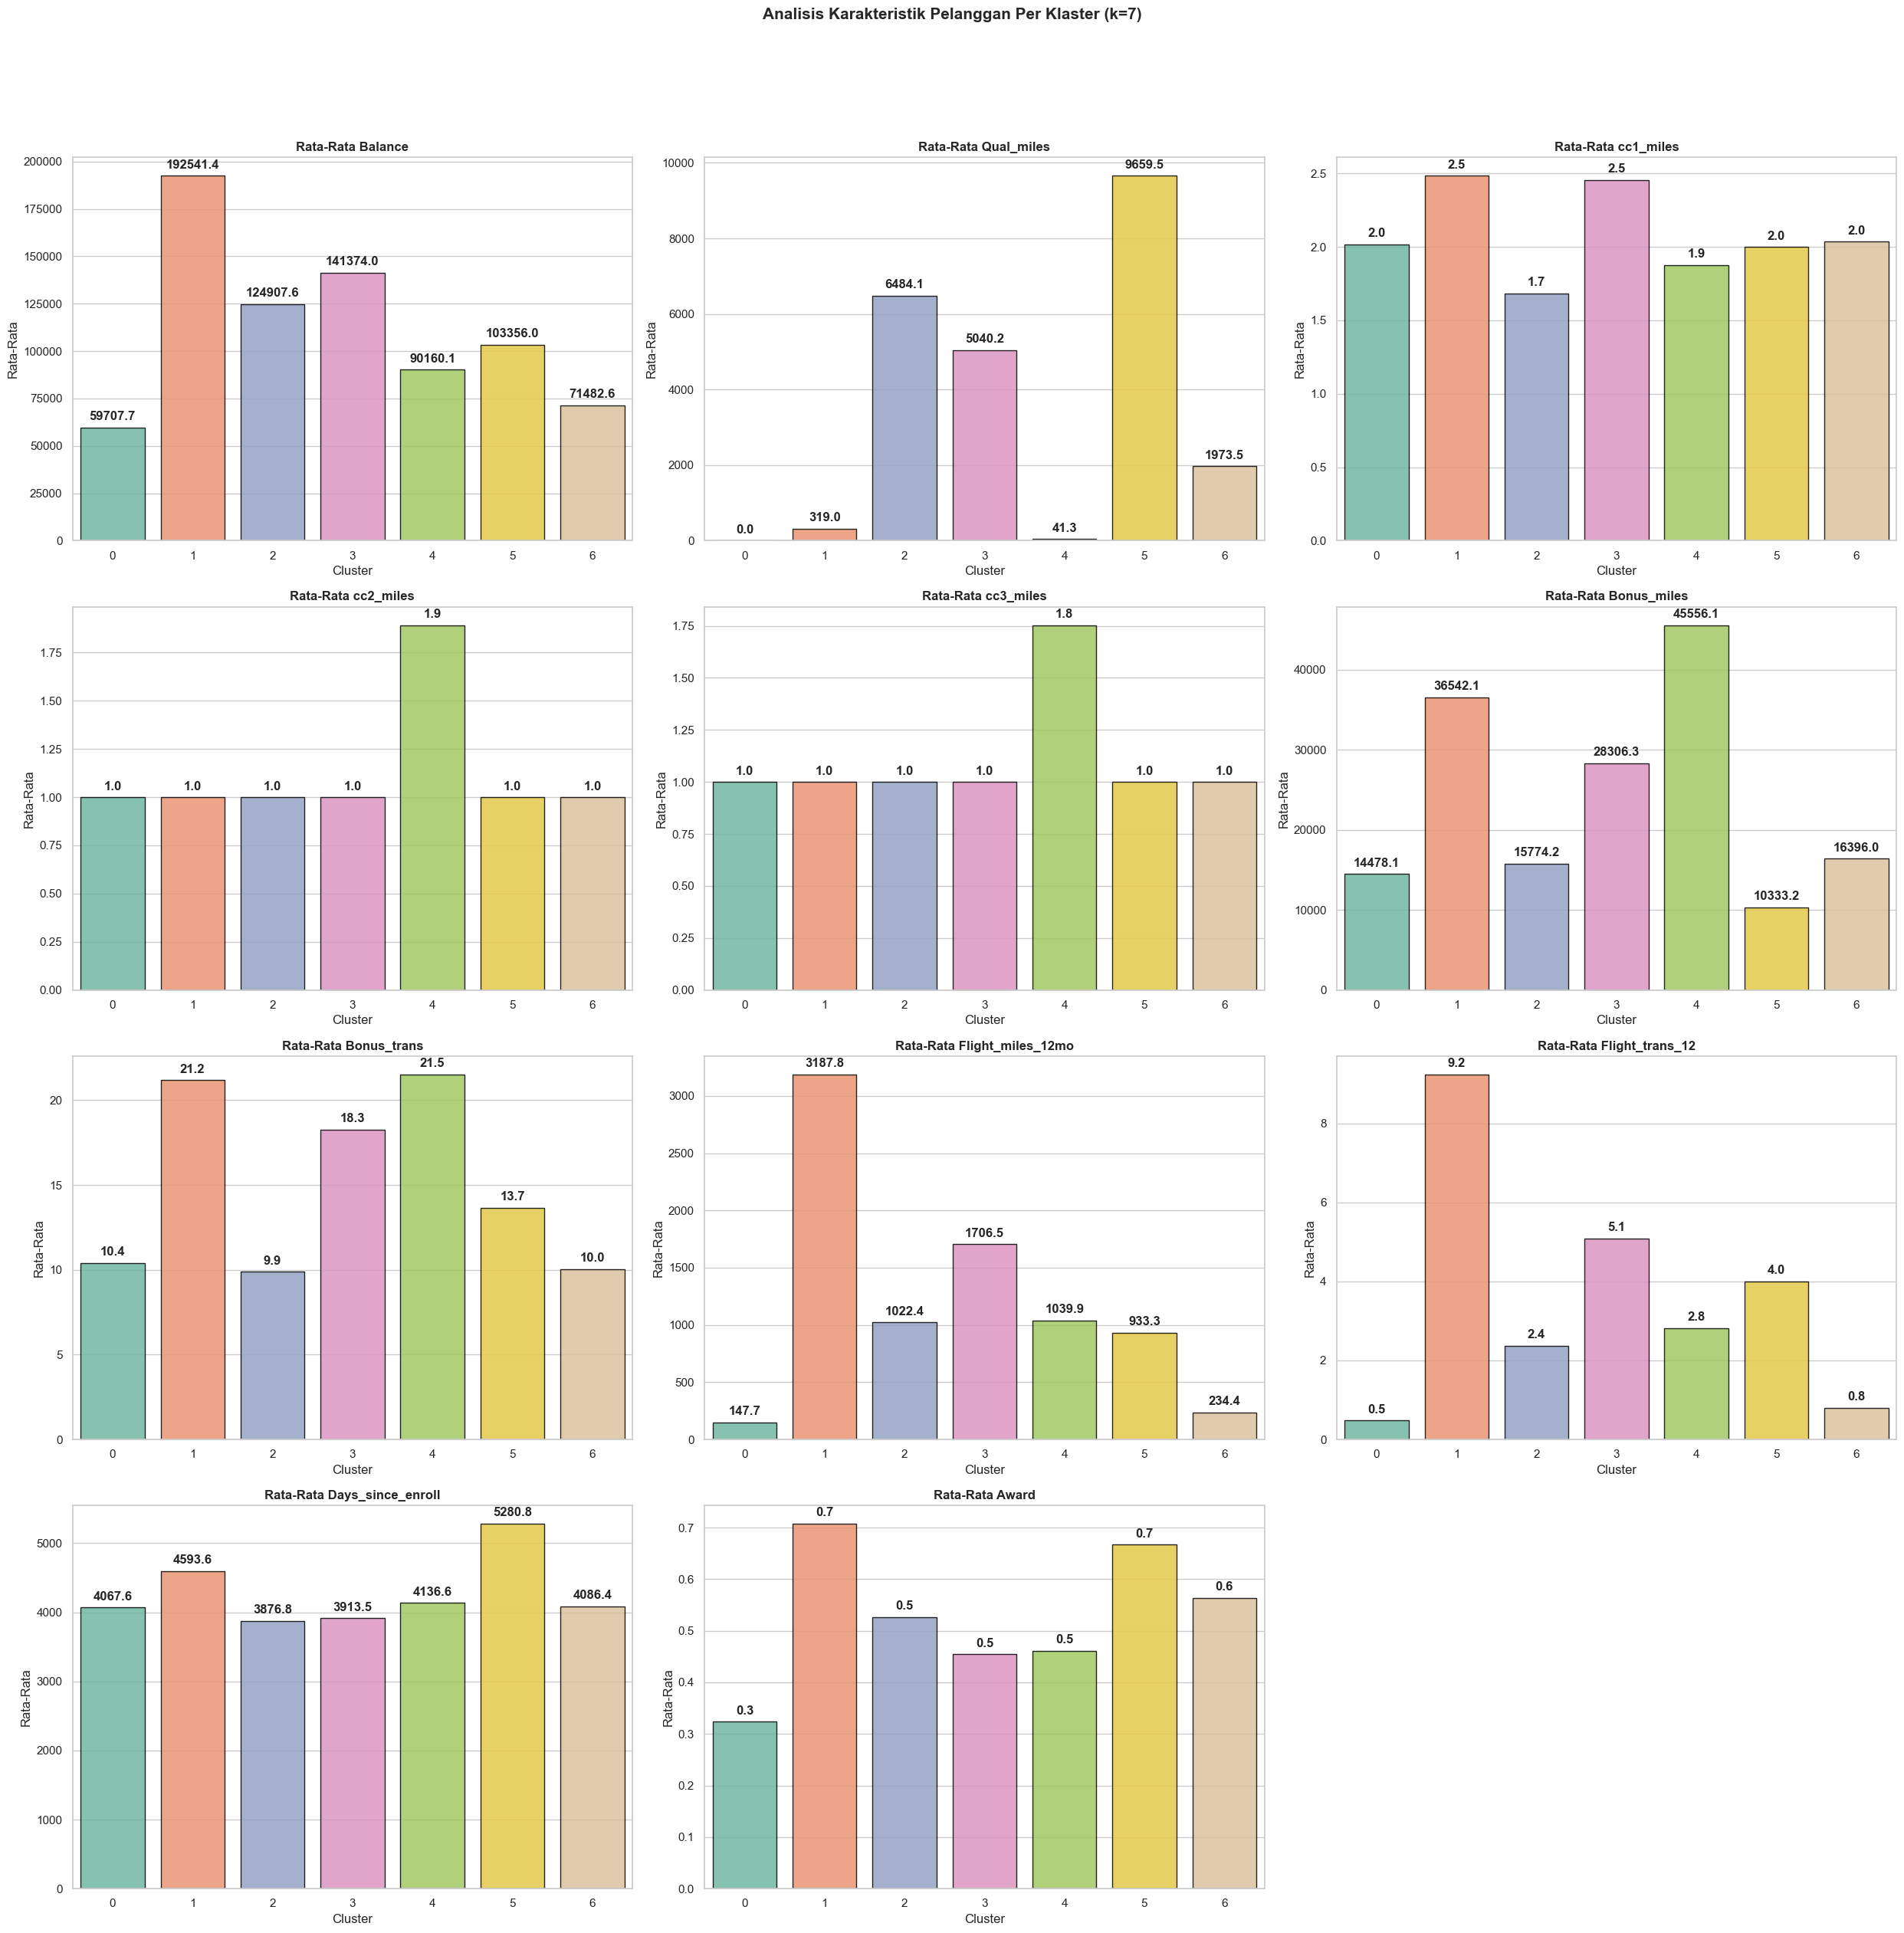

In [9]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
visualizer.plot_cluster_characteristic(num_cols)